In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score

# ==============================
# 🔹 1. Matriz de confusión fija
# Matrix definitions
cm = np.array([
    [309, 9, 9, 1, 0],
    [107, 20, 21, 5, 0],
    [52, 17, 131, 12, 0],
    [3, 2, 16, 85, 0],
    [0, 0, 0, 5, 22]
])


labels = [0, 1, 2, 3, 4]

c0 = 657 / 308
c1 = 302 / 141
c2 = 439 / 206
c3 = 230 / 102
c4 = 31 / 23

In [128]:
def weight_confusion_matrix(cm, expected_totals, c_values=None, return_floats=False):
    """
    Escala cada fila de la matriz de confusión 'cm' para que su suma sea 'expected_totals[i]'.
    - Si c_values es None, los coeficientes se calculan como expected_totals[i] / sum(cm[i]).
    - Si se pasan c_values (floats), se usan tal cual.
    - Devuelve una matriz entera con sumas de fila EXACTAS a expected_totals,
      aplicando redondeo proporcional por residuos. Si return_floats=True, devuelve también la versión float.
    """
    cm = np.asarray(cm, dtype=float)
    expected_totals = np.asarray(expected_totals, dtype=float)

    n_classes = cm.shape[0]
    assert cm.shape[0] == cm.shape[1], "cm debe ser cuadrada"
    assert len(expected_totals) == n_classes, "expected_totals debe tener una entrada por clase"

    # 1) Coeficientes
    if c_values is None:
        row_sums = cm.sum(axis=1)
        c_values = np.zeros(n_classes, dtype=float)
        for i in range(n_classes):
            if row_sums[i] == 0:
                c_values[i] = 0.0  # fila vacía -> quedará todo a 0
            else:
                c_values[i] = expected_totals[i] / row_sums[i]
    else:
        c_values = np.asarray(c_values, dtype=float)
        assert len(c_values) == n_classes, "c_values debe tener una entrada por clase"

    # 2) Matriz ponderada en float
    cm_weighted = cm * c_values[:, None]  # broadcast por fila

    # 3) Redondeo con preservación de suma por fila
    cm_int = np.zeros_like(cm_weighted, dtype=int)
    for i in range(n_classes):
        target = int(round(expected_totals[i]))
        row_float = cm_weighted[i]

        # Si la fila es todo ceros o el target es 0, saltamos
        if np.allclose(row_float, 0) or target == 0:
            cm_int[i] = 0
            continue

        # Redondeo base + ajuste por residuos
        base = np.floor(row_float).astype(int)
        residuals = row_float - base
        deficit = target - base.sum()

        # Si nos faltan unidades, las asignamos a las celdas con mayor residual
        if deficit > 0:
            idx = np.argsort(-residuals)  # de mayor a menor residual
            base[idx[:deficit]] += 1
        # Si sobran unidades por redondeo, las quitamos de los menores residuales
        elif deficit < 0:
            idx = np.argsort(residuals)   # de menor a mayor residual
            base[idx[:(-deficit)]] -= 1

        # Evitar negativos por seguridad
        base = np.clip(base, 0, None)

        # Asegurar suma exacta (por si el clip alteró algo)
        gap = target - base.sum()
        if gap != 0:
            # Reajuste final mínimo: sumamos o restamos a los mayores residuales (o mayores valores)
            order = np.argsort(-row_float) if gap > 0 else np.argsort(row_float)
            k = abs(gap)
            base[order[:k]] += np.sign(gap)

        cm_int[i] = base

    if return_floats:
        return cm_int, cm_weighted
    return cm_int


In [129]:
expected_totals = [657, 302, 439, 230, 31]
cm_weighted_int, cm_weighted_float = weight_confusion_matrix(
    cm, expected_totals, c_values=None, return_floats=True
)

cm = cm_weighted_int

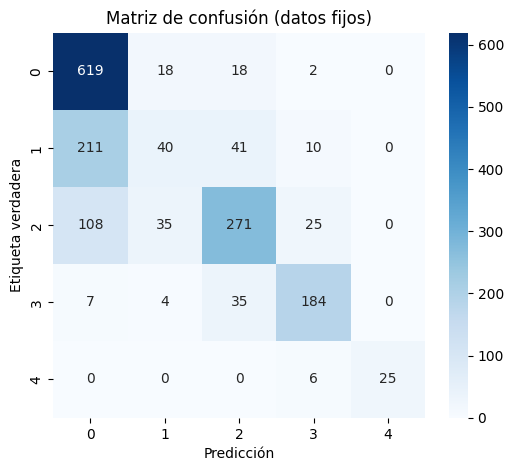

Accuracy: 0.6865581675708258

Reporte por clase:
               precision    recall  f1-score   support

           0     0.6550    0.9422    0.7728       657
           1     0.4124    0.1325    0.2005       302
           2     0.7425    0.6173    0.6741       439
           3     0.8106    0.8000    0.8053       230
           4     1.0000    0.8065    0.8929        31

    accuracy                         0.6866      1659
   macro avg     0.7241    0.6597    0.6691      1659
weighted avg     0.6620    0.6866    0.6492      1659



In [130]:

# ==============================
# 🔹 2. Dibujar matriz
# ==============================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de confusión (datos fijos)")
plt.show()

# ==============================
# 🔹 3. Calcular métricas básicas
# ==============================
# Reconstruimos y_true / y_pred a partir de la matriz
y_true, y_pred = [], []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        y_true.extend([i]*cm[i,j])
        y_pred.extend([j]*cm[i,j])

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nReporte por clase:\n", classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4))
